In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Load Data

LOAD_PATH: str = "../data/raw/king_county_houses.csv"

df=pd.read_csv(LOAD_PATH)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
#EDA
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [16]:
# Look at data types
df.dtypes

date              datetime64[us]
price                    float64
bedrooms                   int64
bathrooms                float64
sqft_living                int64
sqft_lot                   int64
floors                   float64
waterfront                 int64
view                       int64
condition                  int64
grade                      int64
sqft_above                 int64
sqft_basement              int64
yr_built                   int64
yr_renovated               int64
zipcode                    int64
lat                      float64
long                     float64
sqft_living15              int64
sqft_lot15                 int64
house_age                  int64
renovated                  int64
price_per_sqft           float64
log_price                float64
dtype: object

In [17]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns
categorical = df.select_dtypes(include=['object', 'bool']).columns

print("Numerical variables:", numerical)
print("Categorical variables:", categorical)

Numerical variables: Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'house_age', 'renovated',
       'price_per_sqft', 'log_price'],
      dtype='str')
Categorical variables: Index([], dtype='str')


In [18]:
# First, check numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Continuous: numeric with >10 unique values (arbitrary threshold)
continuous_vars = [col for col in numeric_cols if df[col].nunique() > 10]

# Categorical (including ordinal): numeric with <=10 unique values
categorical_vars = [col for col in numeric_cols if df[col].nunique() <= 10]

print("Continuous variables:", continuous_vars)
print("Categorical/Ordinal variables:", categorical_vars)

Continuous variables: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'price_per_sqft', 'log_price']
Categorical/Ordinal variables: ['floors', 'waterfront', 'view', 'condition', 'renovated']


In [19]:
categorical_vars = ['floors', 'waterfront', 'view', 'condition', 'renovated']

for col in categorical_vars:
    print(f"Unique values in {col}: {df[col].unique()}")
    print("-"*40)

Unique values in floors: [1.  2.  1.5 3.  2.5 3.5]
----------------------------------------
Unique values in waterfront: [0 1]
----------------------------------------
Unique values in view: [0 3 4 2 1]
----------------------------------------
Unique values in condition: [3 5 4 1 2]
----------------------------------------
Unique values in renovated: [0 1]
----------------------------------------


In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()
# Most important correlates of price are:  sqft_living, grade, sqft_above, lat

In [68]:
# Summary Statistics for Continuous Variables
numeric_features = ['price', 'sqft_living', 'sqft_lot', 
                    'sqft_basement', 'sqft_living15', 'sqft_lot15',
                    'bedrooms', 'bathrooms', 'house_age', 'sqft_above', 'grade','price_per_sqft']

df[numeric_features].describe()

,price,sqft_living,sqft_lot,sqft_basement,sqft_living15,sqft_lot15,bedrooms,bathrooms,house_age,view,condition,grade,sqft_above,sqft_basement,price_per_sqft
count,2.161300e+04,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,2079.899736,1.510697e+04,291.509045,1986.552492,12768.455652,3.370842,2.114757,43.994864,0.234303,3.409430,7.656873,1788.390691,291.509045,264.156594
std,3.671272e+05,918.440897,4.142051e+04,442.575043,685.391304,27304.179631,0.930062,0.770163,29.373411,0.766318,0.650743,1.175459,828.090978,442.575043,110.060793
min,7.500000e+04,290.000000,5.200000e+02,0.000000,399.000000,651.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,87.588235
25%,3.219500e+05,1427.000000,5.040000e+03,0.000000,1490.000000,5100.000000,3.000000,1.750000,18.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,182.291667
50%,4.500000e+05,1910.000000,7.618000e+03,0.000000,1840.000000,7620.000000,3.000000,2.250000,40.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,244.644550
75%,6.450000e+05,2550.000000,1.068800e+04,560.000000,2360.000000,10083.000000,4.000000,2.500000,64.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,318.322981
max,7.700000e+06,13540.000000,1.651359e+06,4820.000000,6210.000000,871200.000000,33.000000,8.000000,115.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,810.138889


In [84]:
summary = df[numeric_features].describe().round(2)

In [85]:
#Convert to Latex
latex_table = summary.to_latex(
    float_format="%.2f",
    caption="Summary Statistics for Housing Variables",
    label="tab:summary_stats"
)

print(latex_table) 

\begin{table}
\caption{Summary Statistics for Housing Variables}
\label{tab:summary_stats}
\begin{tabular}{lrrrrrrrrrrrrrrr}
\toprule
 & price & sqft_living & sqft_lot & sqft_basement & sqft_living15 & sqft_lot15 & bedrooms & bathrooms & house_age & view & condition & grade & sqft_above & sqft_basement & price_per_sqft \\
\midrule
count & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 & 21613.00 \\
mean & 540088.14 & 2079.90 & 15106.97 & 291.51 & 1986.55 & 12768.46 & 3.37 & 2.11 & 43.99 & 0.23 & 3.41 & 7.66 & 1788.39 & 291.51 & 264.16 \\
std & 367127.20 & 918.44 & 41420.51 & 442.58 & 685.39 & 27304.18 & 0.93 & 0.77 & 29.37 & 0.77 & 0.65 & 1.18 & 828.09 & 442.58 & 110.06 \\
min & 75000.00 & 290.00 & 520.00 & 0.00 & 399.00 & 651.00 & 0.00 & 0.00 & 0.00 & 0.00 & 1.00 & 1.00 & 290.00 & 0.00 & 87.59 \\
25% & 321950.00 & 1427.00 & 5040.00 & 0.00 & 1490.00 & 5100.00 & 3.00 & 1.75 & 18.00 &

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()
# Most important correlates of price are:  sqft_living, grade, sqft_above, lat

In [69]:
#Summary Statistics for Categorical Variables

categorical_features = ['waterfront', 'renovated','view', 'condition', 'floors']

for col in categorical_features:
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'count': counts, 'percent': percents})
    print(f"\n{col}:\n", summary)


waterfront:
             count    percent
waterfront                  
0           21450  99.245824
1             163   0.754176

renovated:
            count    percent
renovated                  
0          20699  95.771064
1            914   4.228936

view:
       count    percent
view                  
0     19489  90.172581
2       963   4.455652
3       510   2.359691
1       332   1.536113
4       319   1.475964

condition:
            count    percent
condition                  
3          14031  64.919262
4           5679  26.275852
5           1701   7.870263
2            172   0.795817
1             30   0.138805

grade:
        count    percent
grade                  
7       8981  41.553695
8       6068  28.075695
9       2615  12.099200
6       2038   9.429510
10      1134   5.246842
11       399   1.846111
5        242   1.119696
12        90   0.416416
4         29   0.134179
13        13   0.060149
3          3   0.013881
1          1   0.004627

floors:
         coun

In [86]:
for col in categorical_features:
    counts = df[col].value_counts()
    percents = (df[col].value_counts(normalize=True) * 100).round(2)
    
    summary = pd.DataFrame({
        'Count': counts,
        'Percent (%)': percents
    })
    
    print(summary.T.to_latex(
        float_format="%.2f",
        caption=f"{col.capitalize()} distribution",
        label=f"tab:{col}"
    ))

\begin{table}
\caption{Waterfront distribution}
\label{tab:waterfront}
\begin{tabular}{lrr}
\toprule
waterfront & 0 & 1 \\
\midrule
Count & 21450.00 & 163.00 \\
Percent (%) & 99.25 & 0.75 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Renovated distribution}
\label{tab:renovated}
\begin{tabular}{lrr}
\toprule
renovated & 0 & 1 \\
\midrule
Count & 20699.00 & 914.00 \\
Percent (%) & 95.77 & 4.23 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{View distribution}
\label{tab:view}
\begin{tabular}{lrrrrr}
\toprule
view & 0 & 2 & 3 & 1 & 4 \\
\midrule
Count & 19489.00 & 963.00 & 510.00 & 332.00 & 319.00 \\
Percent (%) & 90.17 & 4.46 & 2.36 & 1.54 & 1.48 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Condition distribution}
\label{tab:condition}
\begin{tabular}{lrrrrr}
\toprule
condition & 3 & 4 & 5 & 2 & 1 \\
\midrule
Count & 14031.00 & 5679.00 & 1701.00 & 172.00 & 30.00 \\
Percent (%) & 64.92 & 26.28 & 7.87 & 0.80 & 0.14 \\
\bottomrule
\en

<Axes: xlabel='sqft_above', ylabel='Count'>

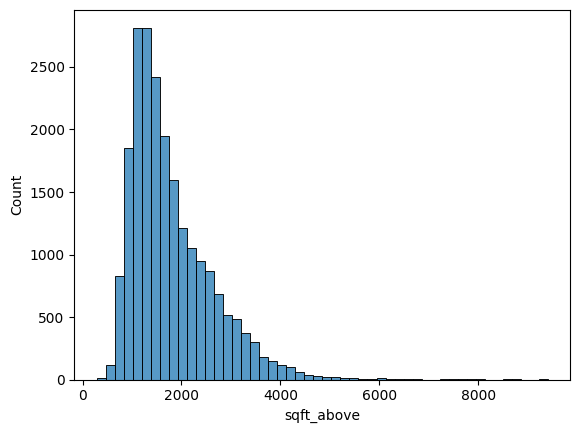

In [70]:
sns.histplot(df["sqft_above"], bins=50)

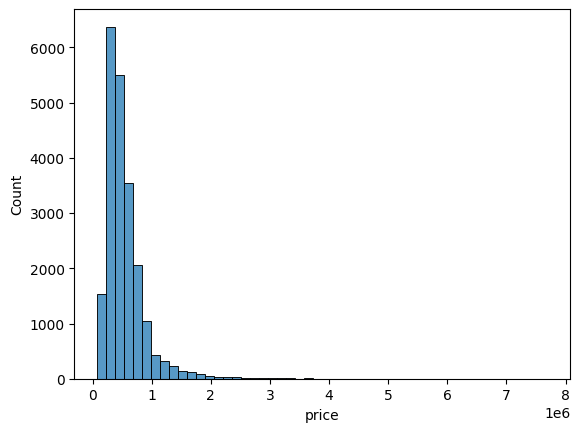

In [72]:
# Check Distribution 
sns.histplot(df["price"], bins=50)
plt.show()



In [13]:
# Take logs of house prices
df["log_price"] = np.log(df["price"])

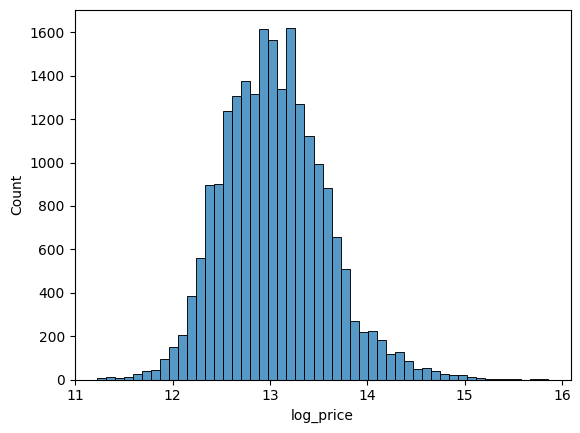

In [15]:
sns.histplot(df["log_price"], bins=50)
plt.show()


In [87]:
# Transform vars to follow normal distribution
df['log_sqft_lot'] = np.log(df['sqft_lot'] + 1)
df['log_sqft_living'] = np.log(df['sqft_living'] + 1)
df['log_sqft_above'] = np.log(df['sqft_above'] + 1)
df['log_sqft_living15'] = np.log(df['sqft_living15'] + 1)
df['log_sqft_lot15'] = np.log(df['sqft_lot15'] + 1)
df['log_price_per_sqft'] = np.log(df['price_per_sqft'] + 1)

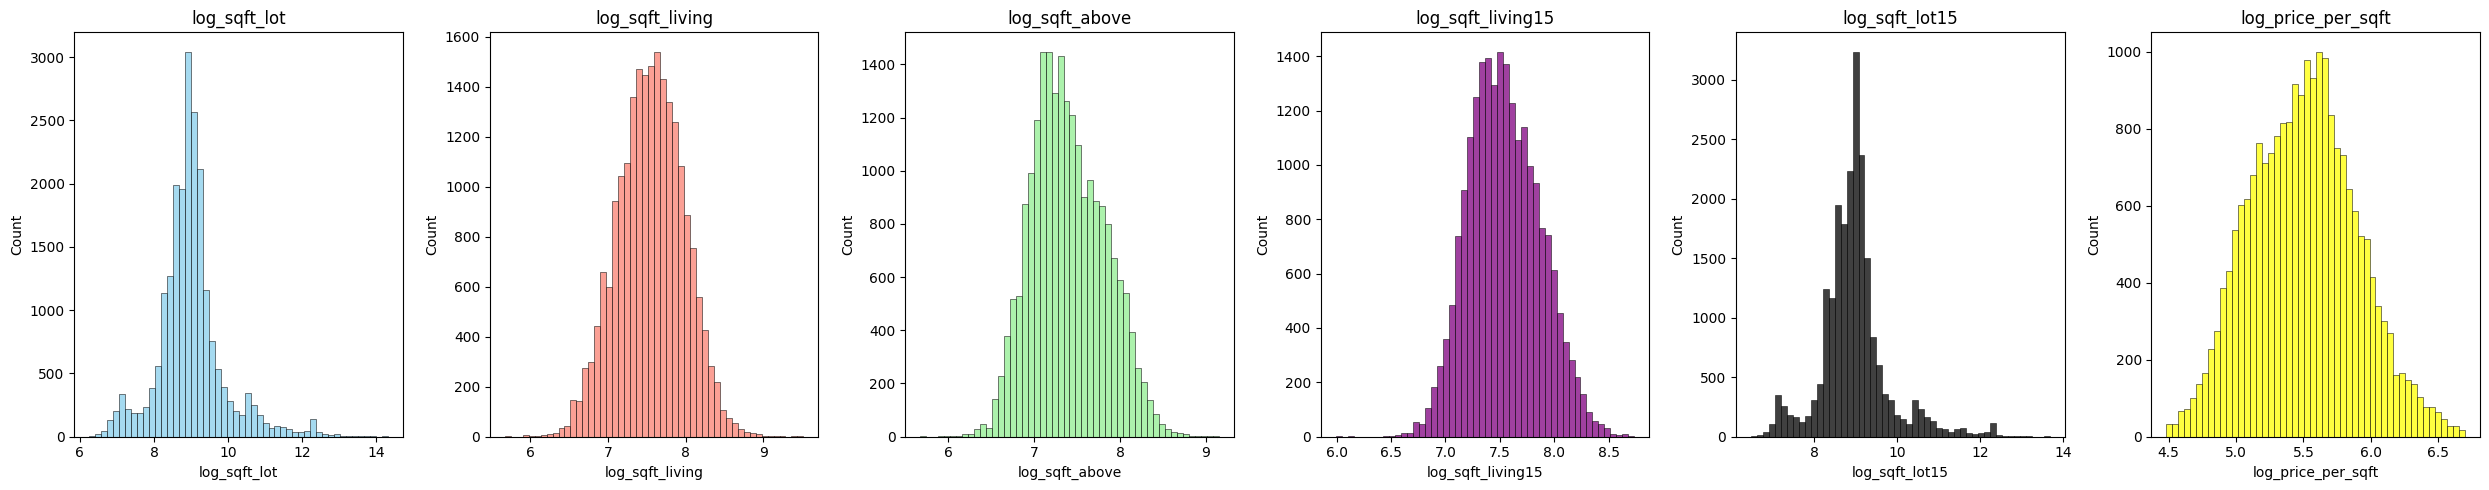

In [88]:
fig, axes = plt.subplots(1, 6, figsize=(25, 5))

sns.histplot(df['log_sqft_lot'], bins=50, ax=axes[0], color='skyblue').set(title='log_sqft_lot')
sns.histplot(df['log_sqft_living'], bins=50, ax=axes[1], color='salmon').set(title='log_sqft_living')
sns.histplot(df['log_sqft_above'], bins=50, ax=axes[2], color='lightgreen').set(title='log_sqft_above')
sns.histplot(df['log_sqft_living15'], bins=50, ax=axes[3], color='purple').set(title='log_sqft_living15')
sns.histplot(df['log_sqft_lot15'], bins=50, ax=axes[4], color='black').set(title='log_sqft_lot15')
sns.histplot(df['log_price_per_sqft'], bins=50, ax=axes[5], color='yellow').set(title='log_price_per_sqft')

plt.tight_layout()
plt.show()

In [31]:
# Create the binary vars
df['waterfront'] = df['waterfront'].astype(int)
df['renovated'] = (df['yr_renovated'] > df['yr_built']).astype(int)


In [32]:
# Create new vars/interaction terms
df['house_age'] = 2015 - df['yr_built']

In [99]:
# Prepare model features

features = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'sqft_basement',
    'bedrooms', 'bathrooms', 'floors', 'waterfront', 'condition', 'grade', 'renovated',
    'house_age', 'lat', 'long', 'log_sqft_living15', 'log_sqft_lot15' 
]

X = df[features]
y = df['log_price']


In [100]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr = LinearRegression()

# Fit on training data
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [103]:
y_pred = lr.predict(X_test)

In [104]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Compute MSE first
mse = mean_squared_error(y_test, y_pred)

# Take square root for RMSE
rmse = np.sqrt(mse)

# R-squared
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE (log price): {rmse:.3f}")
print(f"Test R-squared: {r2:.3f}")

Test RMSE (log price): 0.258
Test R-squared: 0.767


In [105]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

print(y_test[:5])
print(y_pred[:5])

(17290, 16) (4323, 16)
(17290,) (4323,)
735      12.807653
2830     13.670485
4106     13.852806
16218    14.214287
19964    13.474428
Name: log_price, dtype: float64
[13.02116818 13.55737183 13.90265271 14.44713788 13.46668777]


In [106]:
# Check RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (log price, full precision):", rmse)

RMSE (log price, full precision): 0.2575991542852096


In [107]:
# RMSE in log space
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (log price): {rmse_log:.6f}")

# RMSE in dollars
rmse_dollars = np.sqrt(np.mean((np.exp(y_test) - np.exp(y_pred))**2))
print(f"RMSE in dollars: ${rmse_dollars:,.0f}")

RMSE (log price): 0.257599
RMSE in dollars: $202,613


In [108]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
12,lat,1.318347
7,waterfront,0.594650
14,log_sqft_living15,0.263160
2,log_sqft_above,0.204727
9,grade,0.170035
0,log_sqft_living,0.101338
10,renovated,0.073169
5,bathrooms,0.072435
8,condition,0.062384
6,floors,0.047547


In [61]:
#Run Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
r2_score(y_test, y_pred_ridge)

0.7668914556420624

In [109]:
df['is_luxury'] = (df['price'] >= 650000).astype(int)

# Groupby
numeric_features = ['price', 'log_price', 'sqft_living', 'sqft_lot', 
                    'sqft_basement', 'log_sqft_living15', 'log_sqft_lot15',
                    'bedrooms', 'bathrooms', 'floors', 'house_age']

# Group by luxury and compute custom stats
luxury_summary = df.groupby('is_luxury')[numeric_features].agg(['mean','std'])
luxury_summary

price                 log_price            sqft_living  \
                    mean            std       mean       std         mean   
is_luxury                                                                   
0          392819.762355  127276.777911  12.822873  0.353725  1777.470133   
1          990661.889369  477745.372970  13.736043  0.338841  3005.195718   

                            sqft_lot               sqft_basement              \
                   std          mean           std          mean         std   
is_luxury                                                                      
0           634.142511  13091.311192  32778.465245    234.580085  373.286264   
1          1028.645889  21273.952292  60229.813514    465.685575  573.259643   

           ... log_sqft_lot15            bedrooms           bathrooms  \
           ...           mean       std      mean       std      mean   
is_luxury  ...                                                          
0          ...       8.899425  0.789224  3.222727  0.892075  1.931119   
1          ...       9.150020  0.854305  3.824005  0.896912  2.676606   

                       floors            house_age             
                std      mean       std       mean        std  
is_luxury                                                      
0          0.666919  1.422770  0.534473  44.578550  28.230251  
1          0.792677  1.713186  0.496188  42.209053  32.561081  

[2 rows x 22 columns]

In [44]:
categorical_features = ['waterfront', 'renovated']

for col in categorical_features:
    counts = df.groupby('is_luxury')[col].value_counts()
    percents = df.groupby('is_luxury')[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'count': counts, 'percent': percents})
    print(f"\n{col} by luxury status:\n", summary)


waterfront by luxury status:
                       count    percent
is_luxury waterfront                  
0         0           16260  99.821966
          1              29   0.178034
1         0            5190  97.483095
          1             134   2.516905

renovated by luxury status:
                      count    percent
is_luxury renovated                  
0         0          15798  96.985696
          1            491   3.014304
1         0           4901  92.054846
          1            423   7.945154


In [115]:
# CLustering Luxury Homes with KMeans
from sklearn.cluster import KMeans
# Filter only luxury homes
df_luxury = df[df['is_luxury'] == 1]

In [116]:
features = ['log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'sqft_basement',
    'bedrooms', 'bathrooms', 'floors', 'waterfront', 'condition', 'grade', 'renovated',
    'house_age', 'lat', 'long', 'log_sqft_living15', 'log_sqft_lot15' ]
X_luxury = df_luxury[features]

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_luxury)

In [118]:
kmeans = KMeans(n_clusters=3, random_state=42)  
df_luxury['cluster'] = kmeans.fit_predict(X_scaled)

In [119]:
df_luxury.groupby('cluster')[features].mean()

,log_sqft_living,log_sqft_lot,log_sqft_above,sqft_basement,bedrooms,bathrooms,floors,waterfront,condition,grade,renovated,house_age,lat,long,log_sqft_living15,log_sqft_lot15
cluster,,,,,,,,,,,,,,,,
0,7.719452,8.770073,7.443122,567.111990,3.572856,2.238343,1.469817,0.0,3.750624,7.985845,0.120733,64.990008,47.633799,-122.287742,7.630811,8.729303
1,8.148929,9.589540,8.041847,362.303085,4.055595,3.042235,1.922704,0.0,3.213415,9.575323,0.035868,22.298780,47.610472,-122.127308,7.990947,9.488886
2,8.074741,9.709541,7.810399,798.552239,3.507463,2.925373,1.716418,1.0,3.477612,9.186567,0.246269,48.104478,47.565883,-122.250687,7.929571,9.641084


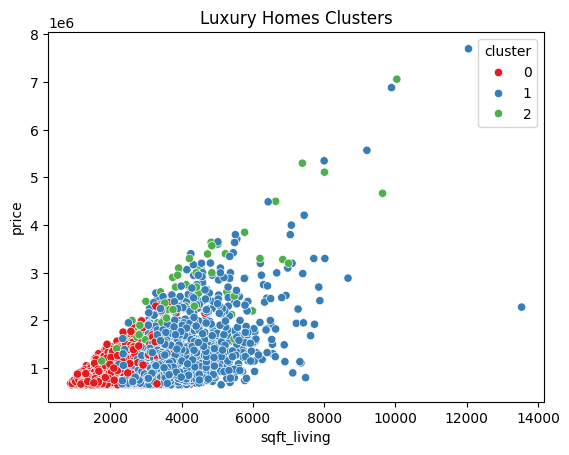

In [121]:
sns.scatterplot(x='sqft_living', y='price', hue='cluster', data=df_luxury, palette='Set1')
plt.title("Luxury Homes Clusters")
plt.show()